# H4 통계적 검증 — 정규성 · 등분산성 확인

**전제 (지금까지 확정된 것들)**
- 안정구간: WEEK_NO 17 ~ 99
- 초반구간(N): 10주 (안정구간 시작 시점부터) — 추후 8주/12주 민감도 체크 예정,  EARLY_N 값만 변경
- 상위 X%: 20% (로렌츠 곡선·kneed 결과 모두 20% 근방에서 일치)
- 이상치는 별도로 제거하지 않음 (도메인상 정상 범위로 판단, 비모수 검정으로 방어)

이 노트북에서는 H4-1의 두 비교(①절대액 변화 paired, ②상위X% vs 나머지 증가폭 independent)를
검정하기 전에 **정규성 · 등분산성부터 확인**하고, 그 결과로 이후 쓸 검정 방법을 확정한다.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available = {f.name for f in fm.fontManager.ttflist}
font_name = next((c for c in candidates if c in available), None)
if font_name:
    plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

pd.set_option('display.max_columns', 100)

DATA_DIR = "data/"
tx = pd.read_csv(DATA_DIR + "transaction_data.csv")

STABLE_MIN_WEEK = 17
STABLE_MAX_WEEK = 99
EARLY_N = 10   # 초반 구간 길이(주)
TOP_X_PCT = 20  # 상위 지출 가구 비율(%)

tx_stable = tx[(tx["WEEK_NO"] >= STABLE_MIN_WEEK) & (tx["WEEK_NO"] <= STABLE_MAX_WEEK)].copy()
print(f"안정구간 데이터: {len(tx_stable):,}행, 가구 {tx_stable['household_key'].nunique():,}개")


안정구간 데이터: 2,317,271행, 가구 2,492개


## 1. 초반 / 후반 구간 정의 및 가구별 지출액 집계

- 초반: 안정구간 시작 후 10주
- 후반: 안정구간 마지막 10주 (초반과 대칭되는 비교 구간)
- 두 구간 모두에 거래가 있는 가구만 비교 대상으로 사용 (paired 비교의 전제조건)


In [2]:
early_window = tx_stable[
    (tx_stable["WEEK_NO"] >= STABLE_MIN_WEEK) &
    (tx_stable["WEEK_NO"] < STABLE_MIN_WEEK + EARLY_N)
]
late_window = tx_stable[
    (tx_stable["WEEK_NO"] > STABLE_MAX_WEEK - EARLY_N) &
    (tx_stable["WEEK_NO"] <= STABLE_MAX_WEEK)
]

print(f"초반 구간: WEEK_NO {STABLE_MIN_WEEK} ~ {STABLE_MIN_WEEK+EARLY_N-1}")
print(f"후반 구간: WEEK_NO {STABLE_MAX_WEEK-EARLY_N+1} ~ {STABLE_MAX_WEEK}")

sales_early = early_window.groupby("household_key")["SALES_VALUE"].sum().rename("sales_early")
sales_late  = late_window.groupby("household_key")["SALES_VALUE"].sum().rename("sales_late")

# 양쪽 구간 모두에 거래가 있는 가구만 사용
panel = pd.concat([sales_early, sales_late], axis=1).dropna()
panel["diff"] = panel["sales_late"] - panel["sales_early"]

print(f"\n양쪽 구간 모두 존재하는 가구 수: {len(panel):,} / 전체 {tx_stable['household_key'].nunique():,}")
panel.describe()


초반 구간: WEEK_NO 17 ~ 26
후반 구간: WEEK_NO 90 ~ 99

양쪽 구간 모두 존재하는 가구 수: 2,095 / 전체 2,492


,sales_early,sales_late,diff
count,2095.000000,2095.000000,2095.000000
mean,367.538186,427.434673,59.896487
std,400.461766,454.194979,374.456691
min,0.790000,0.690000,-2515.820000
25%,99.685000,118.420000,-107.145000
50%,235.770000,276.930000,22.190000
75%,495.765000,589.855000,202.760000
max,3700.550000,5302.680000,2599.110000


## 2. 상위 X% 그룹 정의 (초반구간 기준 고정 — 순환논리 방지)

반드시 **초반 지출액 기준**으로만 순위를 매긴다. panel에 있는 가구 중에서 상위 20%를 뽑는다.


In [3]:
cutoff_value = panel["sales_early"].quantile(1 - TOP_X_PCT/100)
panel["group"] = np.where(panel["sales_early"] >= cutoff_value, "상위20%", "나머지80%")

print(f"상위 {TOP_X_PCT}% 컷오프 지출액(초반 기준): {cutoff_value:.2f}")
print(panel["group"].value_counts())
print("\n그룹별 diff(증가분) 요약")
print(panel.groupby("group")["diff"].describe())


상위 20% 컷오프 지출액(초반 기준): 582.35
group
나머지80%    1676
상위20%      419
Name: count, dtype: int64

그룹별 diff(증가분) 요약
         count        mean         std      min      25%     50%       75%  \
group                                                                        
나머지80%  1676.0  102.743013  301.782339  -521.24  -64.835   36.49  202.0475   
상위20%    419.0 -111.489618  548.345308 -2515.82 -432.820 -131.45  220.9850   

            max  
group            
나머지80%  2599.11  
상위20%   1602.13  


## 3. [비교①: paired] diff(후반-초반) 정규성 확인 — 전체 가구 대상

가구 전체의 diff 분포가 정규분포를 따르는지 확인. 표본 수에 따라 검정 방법을 다르게 선택한다.
- n < 5,000 : Shapiro-Wilk
- n ≥ 5,000 : D'Agostino-Pearson (Shapiro는 큰 표본에서 과민 반응하는 경향이 있어 지양)

시각적으로도 히스토그램 + Q-Q plot을 같이 확인.


In [4]:
diff_all = panel["diff"].values
n = len(diff_all)
print(f"표본 수: {n}")

if n < 5000:
    stat, p = stats.shapiro(diff_all)
    test_name = "Shapiro-Wilk"
else:
    stat, p = stats.normaltest(diff_all)
    test_name = "D'Agostino-Pearson"

print(f"{test_name} 검정: statistic={stat:.4f}, p-value={p:.6f}")
print("→ 정규성 " + ("기각 (정규분포 아님)" if p < 0.05 else "기각 안 됨 (정규분포로 볼 수 있음)"))


표본 수: 2095
Shapiro-Wilk 검정: statistic=0.9092, p-value=0.000000
→ 정규성 기각 (정규분포 아님)


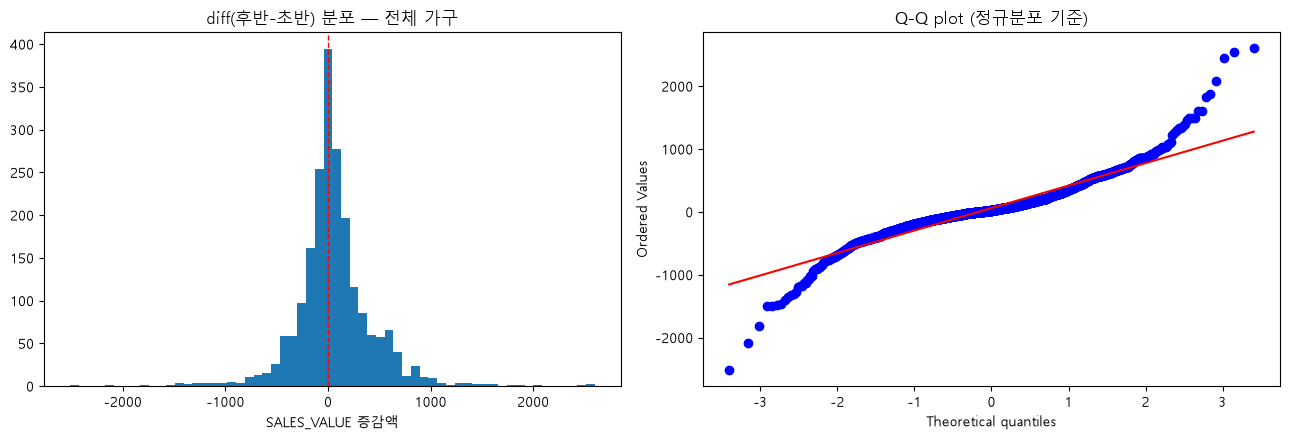

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(diff_all, bins=60)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title("diff(후반-초반) 분포 — 전체 가구")
axes[0].set_xlabel("SALES_VALUE 증감액")

stats.probplot(diff_all, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot (정규분포 기준)")

plt.tight_layout()
plt.show()


## 4. [비교②: independent] 그룹별(상위20% vs 나머지80%) diff 정규성 + 등분산성

두 그룹 간 diff(증가분)를 비교하기 전에, 각 그룹 내 정규성과 두 그룹 간 등분산성을 확인.
- 정규성: 그룹별 Shapiro-Wilk(표본 작을 때) / D'Agostino(표본 클 때)
- 등분산성: Levene 검정 (정규성 가정 없이도 쓸 수 있어 우선 사용)


In [6]:
top_diff  = panel.loc[panel["group"] == "상위20%", "diff"].values
rest_diff = panel.loc[panel["group"] == "나머지80%", "diff"].values

print(f"상위20% 표본 수: {len(top_diff)}, 나머지80% 표본 수: {len(rest_diff)}")

results = []
for name, arr in [("상위20%", top_diff), ("나머지80%", rest_diff)]:
    if len(arr) < 5000:
        stat, p = stats.shapiro(arr)
        test_name = "Shapiro-Wilk"
    else:
        stat, p = stats.normaltest(arr)
        test_name = "D'Agostino-Pearson"
    results.append({"그룹": name, "검정": test_name, "statistic": stat, "p_value": p,
                     "정규성": "기각(비정규)" if p < 0.05 else "기각안됨(정규)"})

normality_summary = pd.DataFrame(results)
normality_summary


상위20% 표본 수: 419, 나머지80% 표본 수: 1676


,그룹,검정,statistic,p_value,정규성
0,상위20%,Shapiro-Wilk,0.985169,2.763608e-04,기각(비정규)
1,나머지80%,Shapiro-Wilk,0.849854,3.382346e-37,기각(비정규)


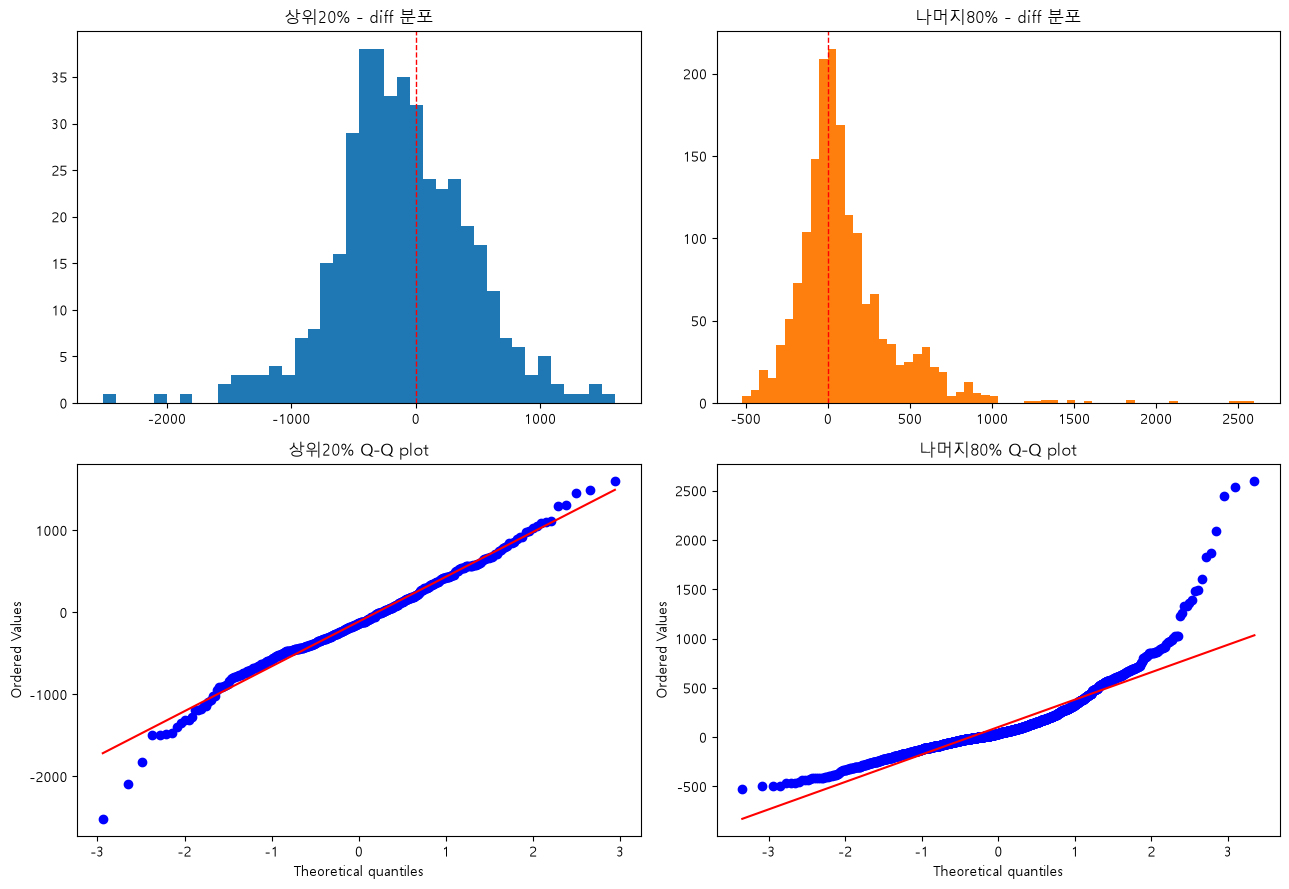

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].hist(top_diff, bins=40, color='C0')
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_title("상위20% - diff 분포")

axes[0,1].hist(rest_diff, bins=60, color='C1')
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0,1].set_title("나머지80% - diff 분포")

stats.probplot(top_diff, dist="norm", plot=axes[1,0])
axes[1,0].set_title("상위20% Q-Q plot")

stats.probplot(rest_diff, dist="norm", plot=axes[1,1])
axes[1,1].set_title("나머지80% Q-Q plot")

plt.tight_layout()
plt.show()


In [8]:
# 등분산성 (Levene 검정 - 정규성 가정 불필요)
levene_stat, levene_p = stats.levene(top_diff, rest_diff)
print(f"Levene 검정: statistic={levene_stat:.4f}, p-value={levene_p:.6f}")
print("→ 등분산 " + ("기각 (분산 다름 → Welch's t-test 필요)" if levene_p < 0.05 else "기각 안 됨 (등분산 가정 가능)"))

print(f"\n상위20% 분산: {np.var(top_diff, ddof=1):.2f}")
print(f"나머지80% 분산: {np.var(rest_diff, ddof=1):.2f}")


Levene 검정: statistic=227.7537, p-value=0.000000
→ 등분산 기각 (분산 다름 → Welch's t-test 필요)

상위20% 분산: 300682.58
나머지80% 분산: 91072.58


## 5. 진단 결과 요약 — 다음 단계에서 쓸 검정 방법 확정

위 결과(정규성 기각 여부 + 등분산성 기각 여부)를 바탕으로, 다음 노트북에서 실제 가설검정에 쓸 방법을 자동으로 표로 정리.


In [9]:
diff_all_normal = p >= 0.05 if n < 5000 else p >= 0.05  # 3번 셀의 p 재사용
top_normal = normality_summary.loc[normality_summary["그룹"]=="상위20%", "p_value"].values[0] >= 0.05
rest_normal = normality_summary.loc[normality_summary["그룹"]=="나머지80%", "p_value"].values[0] >= 0.05
equal_var = levene_p >= 0.05

decision = pd.DataFrame([
    {
        "비교": "①전체 가구 paired (후반-초반)",
        "정규성 충족": diff_all_normal,
        "권장 검정": "대응표본 t-test" if diff_all_normal else "Wilcoxon 부호순위검정",
    },
    {
        "비교": "②상위20% vs 나머지80% (증가분 independent)",
        "정규성 충족": top_normal and rest_normal,
        "등분산 충족": equal_var,
        "권장 검정": (
            "Student's t-test" if (top_normal and rest_normal and equal_var) else
            "Welch's t-test" if (top_normal and rest_normal and not equal_var) else
            "Mann-Whitney U"
        ),
    },
])
decision


,비교,정규성 충족,권장 검정,등분산 충족
0,①전체 가구 paired (후반-초반),False,Wilcoxon 부호순위검정,NaN
1,②상위20% vs 나머지80% (증가분 independent),False,Mann-Whitney U,False


In [10]:
def compute_group_summary(early_n, top_x_pct=TOP_X_PCT):
    """초반구간 길이(early_n)를 바꿔가며 상위X% vs 나머지 그룹의 diff(후반-초반)를 계산"""
    early_w = tx_stable[
        (tx_stable["WEEK_NO"] >= STABLE_MIN_WEEK) &
        (tx_stable["WEEK_NO"] < STABLE_MIN_WEEK + early_n)
    ]
    late_w = tx_stable[
        (tx_stable["WEEK_NO"] > STABLE_MAX_WEEK - early_n) &
        (tx_stable["WEEK_NO"] <= STABLE_MAX_WEEK)
    ]

    s_early = early_w.groupby("household_key")["SALES_VALUE"].sum().rename("sales_early")
    s_late  = late_w.groupby("household_key")["SALES_VALUE"].sum().rename("sales_late")

    p = pd.concat([s_early, s_late], axis=1).dropna()
    p["diff"] = p["sales_late"] - p["sales_early"]

    cutoff = p["sales_early"].quantile(1 - top_x_pct/100)
    p["group"] = np.where(p["sales_early"] >= cutoff, "상위X%", "나머지")

    summary = p.groupby("group")["diff"].agg(["count", "mean", "median", "std"])
    summary["early_n"] = early_n
    return summary.reset_index(), p

results = []
panels = {}
for N in [8, 10, 12]:
    summary, p = compute_group_summary(N)
    results.append(summary)
    panels[N] = p

sensitivity_df = pd.concat(results, ignore_index=True)
sensitivity_df = sensitivity_df[["early_n", "group", "count", "mean", "median", "std"]]
sensitivity_df

,early_n,group,count,mean,median,std
0,8,나머지,1611,92.420118,31.45,253.178658
1,8,상위X%,403,-97.164640,-121.07,449.908931
2,10,나머지,1676,102.743013,36.49,301.782339
3,10,상위X%,419,-111.489618,-131.45,548.345308
4,12,나머지,1731,117.846771,43.43,341.746020
5,12,상위X%,433,-120.211824,-122.73,624.901074


In [11]:
# 부호(방향) 자체가 N에 따라 뒤집히는지 한눈에 확인
pivot = sensitivity_df.pivot(index="early_n", columns="group", values="mean")
pivot["부호_일치"] = (pivot["상위X%"] > 0) == (pivot.get("나머지", pivot.iloc[:,0]*0) ["나머지"] if False else True)  # placeholder 방지용
pivot

group,나머지,상위X%,부호_일치
early_n,,,
8,92.420118,-97.164640,False
10,102.743013,-111.489618,False
12,117.846771,-120.211824,False


In [12]:
# 더 명확한 버전: N별 상위X%/나머지 평균 diff와 부호만 따로 표로
pivot = sensitivity_df.pivot(index="early_n", columns="group", values="mean")
pivot["상위X%_부호"] = np.where(pivot["상위X%"] > 0, "증가(+)", "감소(-)")
pivot["나머지_부호"] = np.where(pivot["나머지"] > 0, "증가(+)", "감소(-)")
pivot

group,나머지,상위X%,상위X%_부호,나머지_부호
early_n,,,,
8,92.420118,-97.164640,감소(-),증가(+)
10,102.743013,-111.489618,감소(-),증가(+)
12,117.846771,-120.211824,감소(-),증가(+)


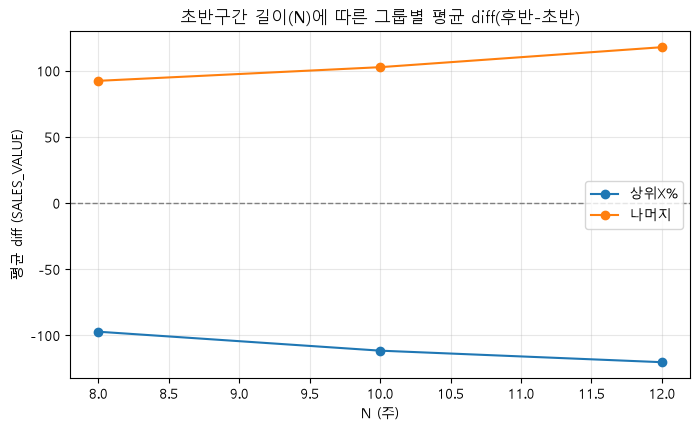

In [13]:
# 시각화: N에 따른 두 그룹의 평균 diff 변화
fig, ax = plt.subplots(figsize=(8, 4.5))
for group in ["상위X%", "나머지"]:
    sub = sensitivity_df[sensitivity_df["group"] == group]
    ax.plot(sub["early_n"], sub["mean"], marker='o', label=group)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title("초반구간 길이(N)에 따른 그룹별 평균 diff(후반-초반)")
ax.set_xlabel("N (주)")
ax.set_ylabel("평균 diff (SALES_VALUE)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [14]:
# 상위X% 그룹의 구성원 자체가 N에 따라 얼마나 겹치는지도 확인 (회귀효과 진단에 참고)
top_households_by_n = {N: set(panels[N][panels[N]["group"]=="상위X%"].index) for N in [8,10,12]}

for n1, n2 in [(8,10), (10,12), (8,12)]:
    overlap = top_households_by_n[n1] & top_households_by_n[n2]
    union = top_households_by_n[n1] | top_households_by_n[n2]
    print(f"N={n1} vs N={n2}: 겹치는 가구 {len(overlap)}개 / 합집합 {len(union)}개 (Jaccard {len(overlap)/len(union):.2f})")

N=8 vs N=10: 겹치는 가구 371개 / 합집합 451개 (Jaccard 0.82)
N=10 vs N=12: 겹치는 가구 395개 / 합집합 457개 (Jaccard 0.86)
N=8 vs N=12: 겹치는 가구 362개 / 합집합 474개 (Jaccard 0.76)


## 다음 단계

- 위 표에서 확정된 검정 방법으로 실제 가설검정 수행 (p-value + 효과크기 + 신뢰구간, 본페로니 보정 포함)
- H4-1의 세 번째 비교(매출 비중 자체의 변화)는 부트스트랩으로 별도 처리 예정
- 8주/12주 민감도 체크는 이 노트북의 `EARLY_N` 값만 바꿔서 동일하게 재실행
